# 05 — Phân loại mức PM2.5 theo dải mục tiêu WHO 2021

WHO 2021 quy định mức hướng dẫn (AQG) và bốn Interim Target cho **trung bình PM2.5 24 giờ**. WHO không công bố hệ nhãn AQI Tốt/Trung bình/Xấu; vì vậy notebook giữ cột `who_band` theo đúng dải mục tiêu WHO và dùng `project_label_vi` chỉ để hiển thị trong hệ thống.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', palette='colorblind')
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
REPORT_PATH = ROOT / 'artifacts' / 'pm25_who_classification_report.json'
DATA_PATH = ROOT / 'data' / 'processed' / 'pm25_who_levels.csv.gz'
report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
columns = [
    'timestamp', 'station_id', 'location_name', 'pm25', 'pm25_24h_mean',
    'pm25_24h_valid_hours', 'who_level_code', 'who_band',
    'project_label_vi', 'exceeds_who_aqg', 'who_assessment_valid'
]
data = pd.read_csv(DATA_PATH, usecols=columns)
data['timestamp'] = pd.to_datetime(data['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
valid = data[data['who_assessment_valid']].copy()
display(pd.Series({
    'Tổng số bản ghi': len(data),
    'Đủ coverage 24 giờ': len(valid),
    'Chưa đủ coverage': len(data) - len(valid),
    'Tỷ lệ vượt AQG (%)': report['exceeds_aqg_percent'],
}).to_frame('Giá trị').round(2))

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_27036\3383085434.py:22: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_PATH, usecols=columns)


,Giá trị
Tổng số bản ghi,267976.00
Đủ coverage 24 giờ,267840.00
Chưa đủ coverage,136.00
Tỷ lệ vượt AQG (%),98.04


## 1. Ngưỡng sử dụng

Giá trị AQG 24 giờ 15 µg/m³ được WHO định nghĩa theo phân vị thứ 99 của phân phối trung bình 24 giờ trong năm, tương đương khoảng 3–4 ngày vượt mỗi năm.

In [2]:
thresholds = pd.DataFrame(report['levels'])[[
    'level_code', 'who_band', 'who_band_vi', 'project_label_vi', 'upper_bound', 'color'
]].rename(columns={
    'level_code': 'Mức', 'who_band': 'Dải WHO', 'who_band_vi': 'Diễn giải dải',
    'project_label_vi': 'Nhãn project', 'upper_bound': 'Cận trên (µg/m³)', 'color': 'Màu'
})
display(thresholds)

,Mức,Dải WHO,Diễn giải dải,Nhãn project,Cận trên (µg/m³),Màu
0,0,≤ AQG,Đạt mức AQG,Đạt khuyến nghị,15.0,#2e7d32
1,1,AQG–IT-4,"Vượt AQG, chưa vượt IT-4",Cần theo dõi,25.0,#f9a825
2,2,IT-4–IT-3,"Vượt IT-4, chưa vượt IT-3",Ô nhiễm mức 1,37.5,#ef6c00
3,3,IT-3–IT-2,"Vượt IT-3, chưa vượt IT-2",Ô nhiễm mức 2,50.0,#d84315
4,4,IT-2–IT-1,"Vượt IT-2, chưa vượt IT-1",Ô nhiễm mức 3,75.0,#8e24aa
5,5,> IT-1,Vượt IT-1,Ô nhiễm nghiêm trọng,NaN,#6d1b1b


## 2. Phân bố mức ô nhiễm

,who_level_code,who_band,project_label_vi,rows,percent
0,0,≤ AQG,Đạt khuyến nghị,5252,1.96
1,1,AQG–IT-4,Cần theo dõi,34151,12.75
2,2,IT-4–IT-3,Ô nhiễm mức 1,70828,26.44
3,3,IT-3–IT-2,Ô nhiễm mức 2,64879,24.22
4,4,IT-2–IT-1,Ô nhiễm mức 3,65002,24.27
5,5,> IT-1,Ô nhiễm nghiêm trọng,27728,10.35


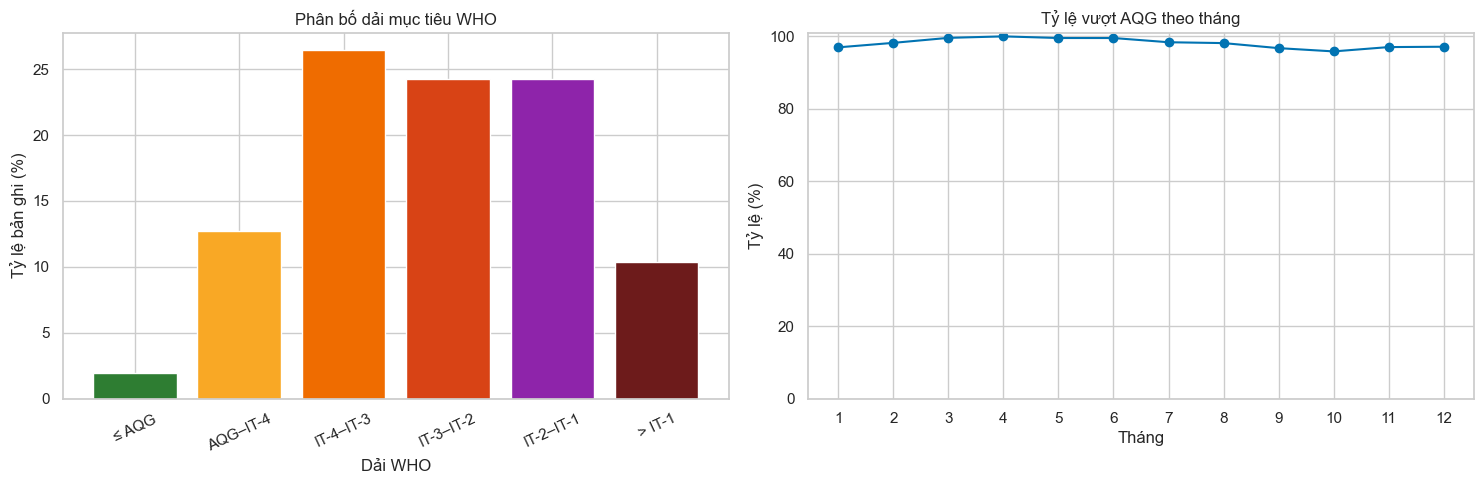

In [3]:
distribution = pd.DataFrame(report['distribution'])
display(distribution[['who_level_code', 'who_band', 'project_label_vi', 'rows', 'percent']].round(2))

colors = [item['color'] for item in report['levels']]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(distribution['who_band'], distribution['percent'], color=colors)
axes[0].set(title='Phân bố dải mục tiêu WHO', xlabel='Dải WHO', ylabel='Tỷ lệ bản ghi (%)')
axes[0].tick_params(axis='x', rotation=25)

monthly = (
    valid.assign(month=valid['timestamp'].dt.month)
    .groupby('month')['exceeds_who_aqg'].mean().mul(100)
)
axes[1].plot(monthly.index, monthly.values, marker='o')
axes[1].set(title='Tỷ lệ vượt AQG theo tháng', xlabel='Tháng', ylabel='Tỷ lệ (%)', xticks=range(1, 13), ylim=(0, 101))
plt.tight_layout()
plt.show()

## 3. So sánh khu vực

,station_id,location_name,pm25_24h_mean,pm25_24h_p95,exceeds_aqg_percent,severe_percent
1,HN_CAU_GIAY,Cau Giay,49.59,92.45,98.99,13.02
7,HN_THANH_XUAN,Thanh Xuan,47.58,91.79,98.98,12.31
0,HN_BA_DINH,Ba Dinh,45.07,86.36,97.75,9.74
2,HN_DONG_DA,Dong Da,45.07,86.36,97.75,9.74
3,HN_HAI_BA_TRUNG,Hai Ba Trung,45.07,86.36,97.75,9.74
5,HN_HOAN_KIEM,Hoan Kiem,45.07,86.36,97.75,9.74
6,HN_LONG_BIEN,Long Bien,45.07,86.36,97.75,9.74
4,HN_HA_DONG,Ha Dong,43.93,84.46,97.58,8.78


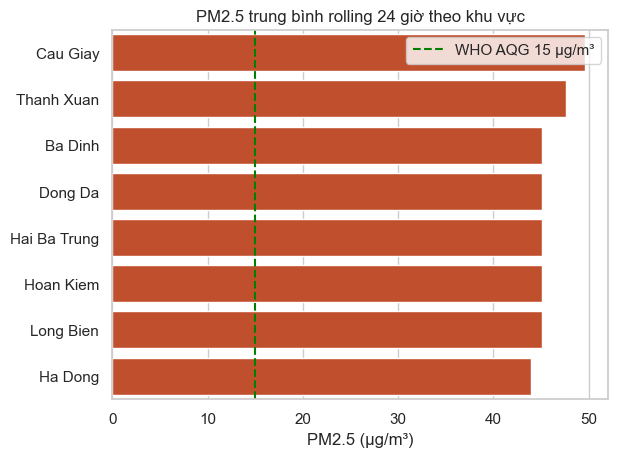

In [4]:
station_summary = valid.groupby(['station_id', 'location_name']).agg(
    pm25_24h_mean=('pm25_24h_mean', 'mean'),
    pm25_24h_p95=('pm25_24h_mean', lambda values: values.quantile(0.95)),
    exceeds_aqg_percent=('exceeds_who_aqg', lambda values: values.mean() * 100),
    severe_percent=('who_level_code', lambda values: values.eq(5).mean() * 100),
).reset_index().sort_values('pm25_24h_mean', ascending=False)
display(station_summary.round(2))

ax = sns.barplot(data=station_summary, y='location_name', x='pm25_24h_mean', color='#d84315')
ax.axvline(report['who_thresholds']['AQG'], linestyle='--', color='green', label='WHO AQG 15 µg/m³')
ax.set(title='PM2.5 trung bình rolling 24 giờ theo khu vực', xlabel='PM2.5 (µg/m³)', ylabel='')
ax.legend()
plt.show()

## 4. Diễn biến theo thời gian

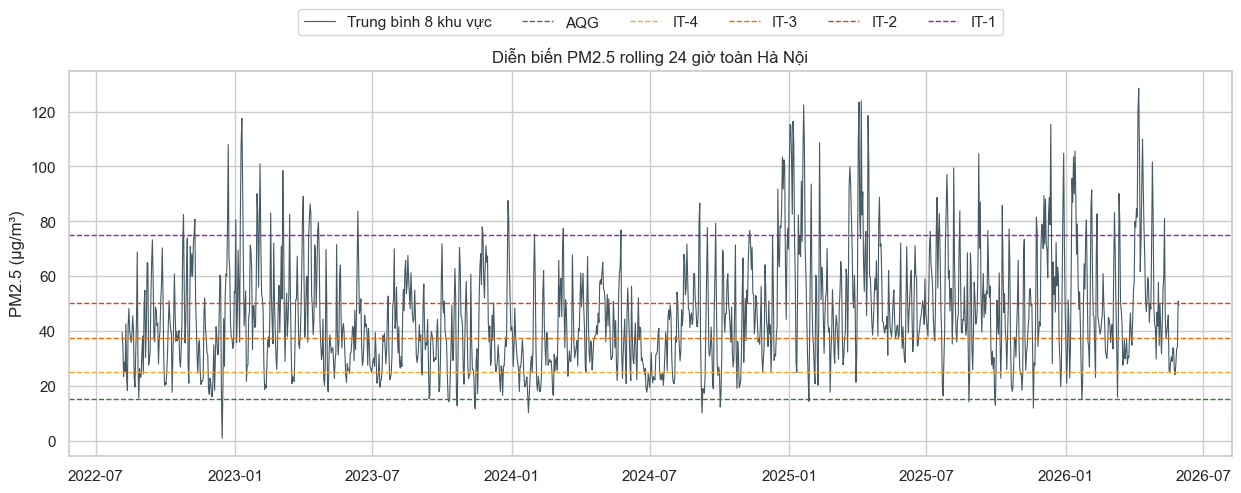

In [5]:
city_daily = (
    valid.set_index('timestamp')
    .groupby(pd.Grouper(freq='D'))['pm25_24h_mean'].mean()
)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(city_daily.index, city_daily.values, linewidth=0.8, color='#455a64', label='Trung bình 8 khu vực')
for name, value, color in [
    ('AQG', 15, '#2e7d32'), ('IT-4', 25, '#f9a825'), ('IT-3', 37.5, '#ef6c00'),
    ('IT-2', 50, '#d84315'), ('IT-1', 75, '#8e24aa')
]:
    ax.axhline(value, linestyle='--', linewidth=1, color=color, label=name)
ax.set(title='Diễn biến PM2.5 rolling 24 giờ toàn Hà Nội', xlabel='', ylabel='PM2.5 (µg/m³)')
ax.legend(ncol=6, loc='upper center', bbox_to_anchor=(0.5, 1.18))
plt.show()

## 5. Kết luận và giới hạn

In [6]:
top_band = distribution.loc[distribution['percent'].idxmax()]
display(Markdown(f'''
- **{report['exceeds_aqg_percent']:.2f}%** bản ghi đủ coverage vượt mức AQG 24 giờ 15 µg/m³.
- Dải xuất hiện nhiều nhất là **{top_band['who_band']}** ({top_band['percent']:.2f}%).
- WHO AQG là hướng dẫn sức khỏe, không phải tiêu chuẩn pháp lý bắt buộc và không phải một thang AQI.
- Dữ liệu của project là ước lượng CAMS tại tám tọa độ đại diện; chưa thể thay thế kết luận từ trạm quan trắc mặt đất.
- Dự báo theo giờ chỉ được gắn `hourly_screening_proxy`. Muốn đánh giá WHO cho tương lai cần dự báo đủ chuỗi để tính trung bình 24 giờ.
'''))


- **98.04%** bản ghi đủ coverage vượt mức AQG 24 giờ 15 µg/m³.
- Dải xuất hiện nhiều nhất là **IT-4–IT-3** (26.44%).
- WHO AQG là hướng dẫn sức khỏe, không phải tiêu chuẩn pháp lý bắt buộc và không phải một thang AQI.
- Dữ liệu của project là ước lượng CAMS tại tám tọa độ đại diện; chưa thể thay thế kết luận từ trạm quan trắc mặt đất.
- Dự báo theo giờ chỉ được gắn `hourly_screening_proxy`. Muốn đánh giá WHO cho tương lai cần dự báo đủ chuỗi để tính trung bình 24 giờ.
